<a href="https://colab.research.google.com/github/alecksandr26/InVision/blob/notebook-detection-model/src/cv-vision/notebooks/InVisionDetectionModelYolov5n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InVision AI: Yolov5n Detection Prototype


**Author**: Erick Alejandro Carrillo López

**Date**: 2026-04-04

This is a colab notebook for desiging the arch and creating the model for detecting the possible opstacules as the first part of the machine leanring system which is going to create.



## Project Overview
This notebook documents the prototype training for the *InVision AI Model* detection layer.
The goal is to implement a lightweight pedestrian obstacle detection system using
a Yolov5n, optimized for edge deployment on hardware like the Raspberry Pi.

## One Drive Connection

To access data from OneDrive, it needs to be connected.

First, you will need to unzip the dataset locally. After unzipping, upload the dataset to your OneDrive account to make it accessible.

### Connect Google Drive
Before running the data pipeline, ensure your dataset is uploaded to your Google Drive. This cell will mount your Drive to the `/content/drive` directory so we can access the COCO data.





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Project Folders Organization
This section defines key constants to standardize the project's folder structure within Google Drive. These variables ensure that all subsequent operations, such as saving models, logs, and configuration files, are directed to their correct locations, making the project more organized and reproducible.

*   `PROJECT_DIR`: The root directory for the entire project in Google Drive.
*   `RUNS_DIR`: The subdirectory where all training runs (checkpoints, logs, results) will be stored.
*   `YAML_FILE`: The path to the YOLOv5 dataset configuration file, which defines the dataset's structure and class names.

In [2]:
PROJECT_DIR = '/content/drive/MyDrive/dataset-invision'
RUNS_DIR = f'{PROJECT_DIR}/runs'
LAST_RUN_DIR = f'{RUNS_DIR}/train2'
YAML_FILE = f'{PROJECT_DIR}/pedestrianobstacledetection/invision.yaml'

# YOLOv5n Model Preparation

This section focuses on setting up and loading the YOLOv5n model for object detection. YOLOv5n is a lightweight and efficient model from the Ultralytics YOLO series, ideal for deployment on edge devices like the Raspberry Pi due to its small size and fast inference capabilities.

The following steps will involve:
1.  **Installation of the Ultralytics Library**: This library provides the necessary tools and classes to work with YOLO models.
2.  **Loading the Pre-trained YOLOv5n Model**: We will load the pre-trained `yolov5n.pt` weights, which have been trained on a large dataset and can detect a wide range of common objects.

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.1 MB/s eta 0:00:00


## Load the Model

After installing the necessary libraries and ensuring the `yolov5n.pt` weights are available, the next crucial step is to load the pre-trained YOLOv5n model. This process initializes the model architecture and populates it with the learned weights, making it ready for inference or further fine-tuning. By loading the model, we can then utilize its object detection capabilities on new images or video streams.

In [4]:
from ultralytics import YOLO  # Import the YOLO class from the ultralytics library.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov5n.pt')  # Initialize the YOLO model with the pretrained 'yolov5n.pt' weights.

### Loading a Previously Trained Model
This section focuses on loading a pre-trained YOLO model, specifically the `best.pt` weights from a previous training run. This is crucial for resuming training, performing inference with the most optimal weights, or continuing development from an already established checkpoint. The model will be initialized with these weights, allowing for direct use without re-training from scratch.

In [5]:
PATH_BEST_MODEL = f'{LAST_RUN_DIR}/weights/best.pt'
model = YOLO(PATH_BEST_MODEL)  # Initialize the YOLO model with the `best.pt` weights from the specified path.

# Dataset Specifications
For this prototype, we are utilizing the **Pedestrian Obstacle Detection** dataset
hosted on Roboflow. This dataset is specifically curated for autonomous
navigation and urban obstacle avoidance.
- **Source:** [Roboflow Universe: Pedestrian Obstacle Detection](https://universe.roboflow.com/pedestrianobstacle/pedestrianobstacledetection/dataset/1)
- **Classes (23):** Including critical navigation markers like `pothole`, `pedestrian`,
  `bad road`, `zebra cross`, `roadblock`, and `puddles`.
- **Image Input Size:** 640 x 640 pixels.
- **Model Output Grid:** 20 x 20 grid (for spatial object localization).
- **Baseline Performance (Reference):**
  ```
  | Metric   | Value |
  |----------+-------|
  | mAP@50   | 82.2% |
  | Precision| 82.7% |
  | Recall   | 78.7% |
  ```

The high class count (**23**) allows the model to distinguish between static
infrastructure (**poles, fences**) and dynamic or hazardous obstacles (**pedestrians, potholes**),
which is essential **for the later LSTM sequence prediction** phase.

In [6]:
import yaml

# Open and read the YAML file containing dataset configuration
with open(YAML_FILE, 'r') as f:
    data = yaml.safe_load(f)

# Extract the 'names' dictionary, which holds class IDs and their corresponding names
CLASS_NAMES = data.get('names', {})

print(f"✅ Found {len(CLASS_NAMES)} classes in Invision dataset:")
print("-" * 40)

# Print each class ID and its name in sorted order for clarity
for class_id in sorted(CLASS_NAMES.keys()):
    print(f"ID {class_id}: {CLASS_NAMES[class_id]}")

✅ Found 23 classes in Invision dataset:
----------------------------------------
ID 0: Pedestrian-Obstacle
ID 1: bad road
ID 2: car
ID 3: chair
ID 4: door
ID 5: drain
ID 6: fence
ID 7: garbage bin
ID 8: gate barrier
ID 9: left turn
ID 10: motorcycle
ID 11: obstacle
ID 12: pedestrian
ID 13: plant pot
ID 14: pole
ID 15: pothole
ID 16: puddle
ID 17: right turn
ID 18: roadblock
ID 19: stair
ID 20: street vendor
ID 21: tree
ID 22: zebra cross


## Prepare YOLOv5 Configuration File

To train the YOLOv5 model with our custom dataset, we need to create a YAML configuration file. This file specifies the paths to our training, validation, and test images, as well as the names of the classes the model will detect. This ensures the model correctly understands the dataset structure and labels during the training process.

To verify that the `invision.yaml` configuration file has been successfully created and saved in the correct directory, we can list the contents of the `pedestrianobstacledetection` folder. This command will display all files and subdirectories, along with their sizes and permissions, ensuring our YAML file is in place before proceeding with model training.

In [ ]:
import yaml

# Definimos la configuración basada en tus rutas y el JSON extraído
config = {
    'path': 'drive/MyDrive/dataset-invision/pedestrianobstacledetection', # Tu path raíz
    'train': 'train', # Now YOLOv5 expects 'train/images' and 'train/labels'
    'val': 'valid',   # Now YOLOv5 expects 'valid/images' and 'valid/labels'
    'test': 'test',   # Now YOLOv5 expects 'test/images' and 'test/labels'
    'names': {
        0: 'Pedestrian-Obstacle', 1: 'bad road', 2: 'car', 3: 'chair', 4: 'door',
        5: 'drain', 6: 'fence', 7: 'garbage bin', 8: 'gate barrier', 9: 'left turn',
        10: 'motorcycle', 11: 'obstacle', 12: 'pedestrian', 13: 'plant pot',
        14: 'pole', 15: 'pothole', 16: 'puddle', 17: 'right turn', 18: 'roadblock',
        19: 'stair', 20: 'street vendor', 21: 'tree', 22: 'zebra cross'
    }
}

# Guardamos el archivo en el path que listaste
yaml_path = '/content/drive/MyDrive/dataset-invision/pedestrianobstacledetection/invision.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print(f"✅ Archivo generado en: {yaml_path}")

In [ ]:
!ls -lha drive/MyDrive/dataset-invision/pedestrianobstacledetection/

total 19K
-rw------- 1 root root  445 Apr  4 07:01 invision.yaml
drwx------ 2 root root 4.0K Apr  4 06:28 .ipynb_checkpoints
-rw------- 1 root root  176 Mar  9 05:32 README.dataset.txt
-rw------- 1 root root 1.4K Mar  9 05:32 README.roboflow.txt
drwx------ 2 root root 4.0K Mar 11 06:04 test
drwx------ 2 root root 4.0K Mar 11 06:04 train
drwx------ 2 root root 4.0K Mar 11 06:04 valid


In [ ]:
!rm drive/MyDrive/dataset-invision/pedestrianobstacledetection/train.cache
!rm drive/MyDrive/dataset-invision/pedestrianobstacledetection/valid.cache

In [ ]:
import yaml

# Define the configuration based on your paths and the extracted JSON
config = {
    'path': 'drive/MyDrive/dataset-invision/pedestrianobstacledetection', # Your root path
    'train': 'train', # Now YOLOv5 expects 'train/images' and 'train/labels'
    'val': 'valid',   # Now YOLOv5 expects 'valid/images' and 'valid/labels'
    'test': 'test',   # Now YOLOv5 expects 'test/images' and 'test/labels'
    'names': {
        0: 'Pedestrian-Obstacle', 1: 'bad road', 2: 'car', 3: 'chair', 4: 'door',
        5: 'drain', 6: 'fence', 7: 'garbage bin', 8: 'gate barrier', 9: 'left turn',
        10: 'motorcycle', 11: 'obstacle', 12: 'pedestrian', 13: 'plant pot',
        14: 'pole', 15: 'pothole', 16: 'puddle', 17: 'right turn', 18: 'roadblock',
        19: 'stair', 20: 'street vendor', 21: 'tree', 22: 'zebra cross'
    }
}

# Save the file to the path you listed
yaml_path = '/content/drive/MyDrive/dataset-invision/pedestrianobstacledetection/invision.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print(f"✅ File generated at: {yaml_path}")

✅ File generated at: /content/drive/MyDrive/dataset-invision/pedestrianobstacledetection/invision.yaml


### Convert COCO Annotations to YOLO Format

The dataset is currently annotated in COCO format, which is typically stored in JSON files. YOLOv5, however, expects annotations in its own text-based format (`.txt` files for each image). This utility function will parse the COCO JSON annotation files and convert them into the YOLO format, creating a `labels/` subdirectory within each data split (train, valid, test) and populating it with the corresponding YOLO `.txt` files.

In [ ]:
import json
import os

def convert_coco_to_yolo(json_path, output_dir):
    with open(json_path, 'r') as f:
        data = json.load(f)

    os.makedirs(output_dir, exist_ok=True)

    # Create a dictionary to map images to their annotations
    images = {img['id']: img for img in data['images']}

    for ann in data['annotations']:
        img_id = ann['image_id']
        img_info = images[img_id]
        img_w, img_h = img_info['width'], img_info['height']

        # COCO format: [x_min, y_min, width, height]
        # YOLO format: [class_id, x_center, y_center, width, height] (normalized)
        x_min, y_min, w, h = ann['bbox']
        x_center = (x_min + w / 2) / img_w
        y_center = (y_min + h / 2) / img_h
        norm_w = w / img_w
        norm_h = h / img_h

        # COCO category_id is 1-indexed, YOLO expects 0-indexed if starting from 0
        # Ensure class_id is correctly mapped to your dataset's names dictionary later if needed.
        # For now, we use the raw category_id from COCO.
        class_id = ann['category_id']

        # Construct the label file name based on the image file name
        # Replace original extension with .txt
        img_filename_without_ext = os.path.splitext(img_info['file_name'])[0]
        label_file = os.path.join(output_dir, img_filename_without_ext + '.txt')

        with open(label_file, 'a') as f:
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

# Base paths for the dataset
base_path = 'drive/MyDrive/dataset-invision/pedestrianobstacledetection'

# Execute conversion for the training set
print("Converting training annotations...")
convert_coco_to_yolo(
    json_path=f'{base_path}/train/_annotations.coco.json',
    output_dir=f'{base_path}/train/labels'
)

# Execute conversion for the validation set
print("Converting validation annotations...")
convert_coco_to_yolo(
    json_path=f'{base_path}/valid/_annotations.coco.json',
    output_dir=f'{base_path}/valid/labels'
)

# Assuming there is also a test set that needs conversion
print("Converting test annotations...")
convert_coco_to_yolo(
    json_path=f'{base_path}/test/_annotations.coco.json',
    output_dir=f'{base_path}/test/labels'
)

print("✅ COCO to YOLO annotation conversion completed. You should now have a 'labels' folder in each directory (train, valid, test) with the corresponding .txt files.")

Converting training annotations...
Converting validation annotations...
Converting test annotations...
✅ COCO to YOLO annotation conversion completed. You should now have a 'labels' folder in each directory (train, valid, test) with the corresponding .txt files.


### Organize YOLO Dataset Folders

This script ensures that the dataset is structured correctly for YOLOv5 training. It will create `images/` subdirectories within each `train`, `valid`, and `test` split, and move all image files into these respective subdirectories. This is a common requirement for YOLO models to correctly locate image data during training.

In [ ]:
import os
import shutil
from glob import glob

def organize_yolo_folders(base_path):
    splits = ['train', 'valid', 'test']
    # Common image extensions
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG']

    for split in splits:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            print(f"⚠️ Skipping {split}, folder not found.")
            continue

        # 1. Create destination subfolders
        images_dir = os.path.join(split_path, 'images')
        labels_dir = os.path.join(split_path, 'labels') # Ensure labels dir exists as well
        os.makedirs(images_dir, exist_ok=True)
        os.makedirs(labels_dir, exist_ok=True)

        # 2. Move images to the /images folder
        image_files = []
        for ext in extensions:
            image_files.extend(glob(os.path.join(split_path, ext)))

        for img in image_files:
            # Avoid moving if already in the correct folder
            if 'images' not in img:
                shutil.move(img, os.path.join(images_dir, os.path.basename(img)))

        print(f"✅ Organized {split}: Images moved to {images_dir}")

# Execute with your Drive path
dataset_path = '/content/drive/MyDrive/dataset-invision/pedestrianobstacledetection'
organize_yolo_folders(dataset_path)

✅ Organized train: Images moved to /content/drive/MyDrive/dataset-invision/pedestrianobstacledetection/train/images
✅ Organized valid: Images moved to /content/drive/MyDrive/dataset-invision/pedestrianobstacledetection/valid/images
✅ Organized test: Images moved to /content/drive/MyDrive/dataset-invision/pedestrianobstacledetection/test/images


After running the conversion script, it's crucial to verify that the `labels` folders have been created and contain the `.txt` annotation files. Let's list the contents of the `train/labels/` directory to confirm.

In [ ]:
!ls -F drive/MyDrive/dataset-invision/pedestrianobstacledetection/train/labels/ | head -n 5

gambar-1001-_jpg.rf.8391abd5792c5ef2d95e6bb0934c15aa.txt
gambar-1001-_jpg.rf.83ce4fc12b1e8bd3439ad7cc1af4286d.txt
gambar-1001-_jpg.rf.a692ad951a46603851b860340c4c785a.txt
gambar-1002-_jpg.rf.2708c96c3cab3f05359650ccef31bf37.txt
gambar-1002-_jpg.rf.62944d3334b52abfe59c0b62d86abdd8.txt


In [ ]:
!ls -F drive/MyDrive/dataset-invision/pedestrianobstacledetection/train/images/ | head -n 5

gambar-1001-_jpg.rf.8391abd5792c5ef2d95e6bb0934c15aa.jpg
gambar-1001-_jpg.rf.83ce4fc12b1e8bd3439ad7cc1af4286d.jpg
gambar-1001-_jpg.rf.a692ad951a46603851b860340c4c785a.jpg
gambar-1002-_jpg.rf.2708c96c3cab3f05359650ccef31bf37.jpg
gambar-1002-_jpg.rf.62944d3334b52abfe59c0b62d86abdd8.jpg


Now that the YOLO-formatted labels should be in place, we need to ensure that the `invision.yaml` file is correctly configured to point to the image directories. The YOLOv5 model will automatically look for the `labels` subdirectory alongside the `images` directory specified in the config.

I will update the `invision.yaml` definition in cell `eQPBfpSTK7nL` to point to the `train`, `valid`, and `test` root directories, and it will be implicitly assumed that `images` and `labels` subdirectories exist within each. Please re-run that cell after this modification, and then re-attempt the training.

# Training the YOLOv5n Model

This section outlines the process of training the YOLOv5n model using our custom dataset. We will configure the training parameters, including image size, number of epochs, and batch size, along with various data augmentation techniques to improve the model's robustness and generalization capabilities. The training process will leverage the `invision.yaml` configuration file created earlier, which defines the dataset paths and class names.

In [7]:
IMG_SIZE = 640    # Image input resolution (640x640 pixels)
EPOCHS = 100      # Number of training epochs
BATCH = 32        # Batch size

In [ ]:

model.train(
    data=YAML_FILE,     # Your config file path
    imgsz=IMG_SIZE,                # RGB image resolution 640x640
    epochs=EPOCHS,               # Will create a 'best.pt' checkpoint if validation improves
    batch=BATCH,                 # Adjust according to your T4 GPU RAM

    # --- Data Augmentation parameters ---
    fliplr=0.5,               # Horizontal flip (your tf.random.uniform([]) > 0.5)
    hsv_s=0.3,                # HSV saturation (similar to your lower=0.7, upper=1.3)
    hsv_v=0.2,                # HSV value/brightness (similar to your max_delta=0.2)

    # --- Additional YOLO features for better Recall ---
    mosaic=1.0,               # Combines 4 images (great for learning)
    patience=20,              # Early stopping if validation metric doesn't improve for 20 epochs
    save=True,                 # Saves checkpoints at each epoch
    project=RUNS_DIR,
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=drive/MyDrive/dataset-invision/pedestrianobstacledetection/invision.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

## Tranning Restuls


## Training Results Interpretation

The training process yielded the following key metrics in the last epoch, offering valuable insights into the model's performance:

| Metric       | Current Value | Interpretation                                                                                                                                                                                                                                    |
|:-------------|:--------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Precision**| 0.7337        | This indicates that **out of all objects the model detected, approximately 73.37% were actually correct detections.** A high precision value means the model is good at avoiding false positives (not detecting something that isn't there).    |
| **Recall**   | 0.7550        | This means that **the model successfully identified approximately 75.50% of all actual objects present in the images.** A high recall value suggests the model is effective at finding most of the relevant objects, minimizing false negatives.         |
| **mAP@50**   | 0.7732        | **Mean Average Precision at an Intersection over Union (IoU) threshold of 0.50.** This is a widely used metric that evaluates both precision and recall. A value of 0.7732 is a very good general balance, indicating strong overall detection capabilities for the 23 classes in your dataset. |
| **mAP@50-95**| 0.5086        | **Mean Average Precision averaged across multiple IoU thresholds from 0.50 to 0.95.** This metric is more stringent than mAP@50. A value of 0.5086 suggests that when the model detects an object, its bounding box is quite well-adjusted to the actual object's boundaries, even at stricter overlap requirements.                                   |
| **Box Loss** | 1.2594        | This loss function measures how accurately the model predicts the bounding box coordinates (location and size) of objects. A lower value is better, indicating more precise localization.                                                              |
| **Class Loss** | 1.0250        | This loss function evaluates how well the model classifies objects into their correct categories. A lower value indicates better classification accuracy.                                                                                           |
| **DFL Loss** | 1.3419        | **Distribution Focal Loss** is a loss function designed to improve bounding box regression, particularly for handling difficult examples and imbalances in localization quality. A lower value means better localization refinement.                     |

### Overall Insights:

*   **Strong Performance:** The mAP@50 of 0.7732 is commendable, especially for a dataset with 23 classes, indicating a robust model that balances identifying objects correctly (precision) and finding most objects (recall).
*   **Good Localization:** The mAP@50-95 at 0.5086 suggests that not only does the model identify objects well, but it also places its bounding boxes quite accurately around them.
*   **Training Progression:** Observing the `train/box_loss`, `train/cls_loss`, and `train/dfl_loss` alongside their validation counterparts (`val/box_loss`, `val/cls_loss`, `val/dfl_loss`) shows the model's learning process. Ideally, both train and validation losses should decrease and converge. Any significant divergence might indicate overfitting or underfitting, which would require further tuning of hyperparameters or data augmentation strategies.

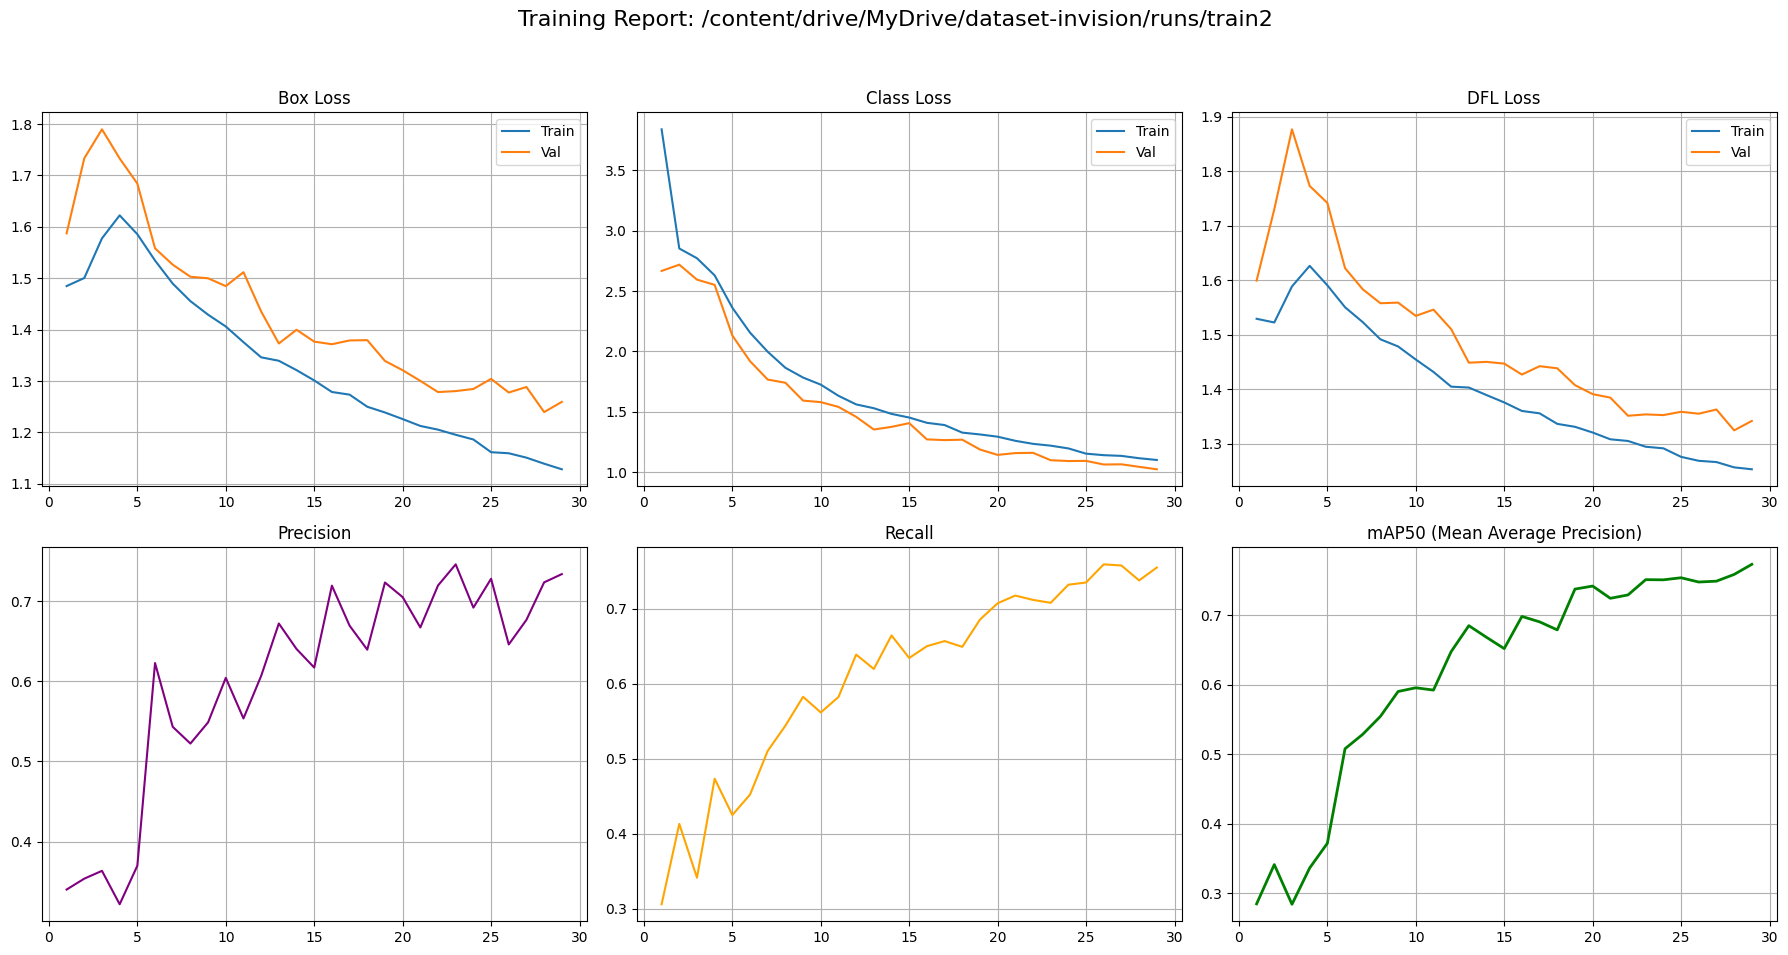


🚀 Last Epoch (29): mAP50 = 0.7732 | Box Loss = 1.2594
   Precision = 0.7337 | Recall = 0.7550 | mAP50-95 = 0.5086


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to the results CSV file generated by YOLOv5 training
csv_path = f'{LAST_RUN_DIR}/results.csv'

# Check if the results file exists before proceeding
if not os.path.exists(csv_path):
    print(f"Error: Results file not found at {csv_path}")
else:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_path)
    # Clean column names by stripping whitespace
    df.columns = [c.strip() for c in df.columns]

    # Create a 2x3 grid of subplots for visualizing training metrics
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    # Set the main title for the entire figure, indicating the training run
    fig.suptitle(f'Training Report: {LAST_RUN_DIR}', fontsize=16)

    # --- ROW 1: LOSSES ---
    # Plot Box Loss (measures the accuracy of bounding box predictions)
    axs[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train')
    axs[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val')
    axs[0, 0].set_title('Box Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Plot Class Loss (measures the accuracy of object classification)
    axs[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train')
    axs[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val')
    axs[0, 1].set_title('Class Loss')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Plot DFL Loss (Distribution Focal Loss for improved bounding box localization)
    axs[0, 2].plot(df['epoch'], df['train/dfl_loss'], label='Train')
    axs[0, 2].plot(df['epoch'], df['val/dfl_loss'], label='Val')
    axs[0, 2].set_title('DFL Loss')
    axs[0, 2].legend()
    axs[0, 2].grid(True)

    # --- ROW 2: ACCURACY METRICS ---
    # Plot Precision (proportion of positive identifications that were actually correct)
    axs[1, 0].plot(df['epoch'], df['metrics/precision(B)'], color='purple')
    axs[1, 0].set_title('Precision')
    axs[1, 0].grid(True)

    # Plot Recall (proportion of actual positives that were identified correctly)
    axs[1, 1].plot(df['epoch'], df['metrics/recall(B)'], color='orange')
    axs[1, 1].set_title('Recall')
    axs[1, 1].grid(True)

    # Plot mAP50 (Mean Average Precision at an IoU threshold of 0.50)
    axs[1, 2].plot(df['epoch'], df['metrics/mAP50(B)'], color='green', linewidth=2)
    axs[1, 2].set_title('mAP50 (Mean Average Precision)')
    axs[1, 2].grid(True)

    # Adjust layout to prevent overlapping titles/labels
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # Display the plots
    plt.show()

    # Display the last epoch's key performance metrics for quick reference
    ultimo = df.iloc[-1]
    print(f"\n🚀 Last Epoch ({int(ultimo['epoch'])}): mAP50 = {ultimo['metrics/mAP50(B)']:.4f} | Box Loss = {ultimo['val/box_loss']:.4f}")
    print(f"   Precision = {ultimo['metrics/precision(B)']:.4f} | Recall = {ultimo['metrics/recall(B)']:.4f} | mAP50-95 = {ultimo['metrics/mAP50-95(B)']:.4f}")

### Labels: A Radiography of Your Dataset

This image is fundamental because it's the **radiography of your dataset**. YOLO automatically generates it to tell you: "Brother, this is what you gave me to learn from."

If the model doesn't know what a pothole or a pedestrian looks like, it's because of what you see here. Let's analyze the 4 panels of your `labels.jpg`:

---

### 1. Class Histogram (Top Left)
*   **What you see:** A bar chart with IDs from 0 to 22.
*   **Purpose:** To see the **data balance**.
*   **Interpretation:** If one bar is huge (e.g., `pedestrian`) and another is almost invisible (e.g., `pothole`), the model will be an expert in people but ignorant of potholes. This is called *Class Imbalance*. If you notice this, you need more photos of the "smaller" classes.

### 2. Bounding Box Correlation (Top Right)
*   **What you see:** Thousands of overlapping rectangles.
*   **Purpose:** To see the **shape and scale** of your labels.
*   **Interpretation:** You'll see that most boxes are in the lower half of the image. This makes sense for **Invision**, as obstacles are often on the ground where the user walks. If you see boxes covering the entire image, they are large objects or very close-up photos.

### 3. Location Heatmap (Bottom Left)
*   **What you see:** A square that is usually brighter (yellow/red) in certain areas.
*   **Purpose:** To see the **Center of Objects** ($x$ and $y$).
*   **Interpretation:** If the brightness is concentrated in the lower center, the model will learn that obstacles "usually" appear there. It's dangerous if the brightness is a perfect spot in the center, because the model might become "lazy" and only look for things in the middle.

### 4. Size Distribution (Bottom Right)
*   **What you see:** A scatter plot of Width ($width$) vs. Height ($height$).
*   **Purpose:** To see the **variety of shapes**.
*   **Interpretation:**
    *   Points on a vertical line: Thin and tall objects (poles, people).
    *   Points on a horizontal line: Wide objects (zebra crossings, potholes).
    *   Points near the origin $(0,0)$: Very distant or small objects.

---

### Why does this matter for the code?
If this chart shows you that ID 15 (`pothole`) has almost no data, and you expect the model to detect it, you now know why it will fail.

> **Golden rule:** If in panel 1 (Histogram) you see that an important class is almost empty, it is better for your Python logic to return a **-1** or a "Insufficient data" message for that class, because the model will be "guessing" more than detecting.

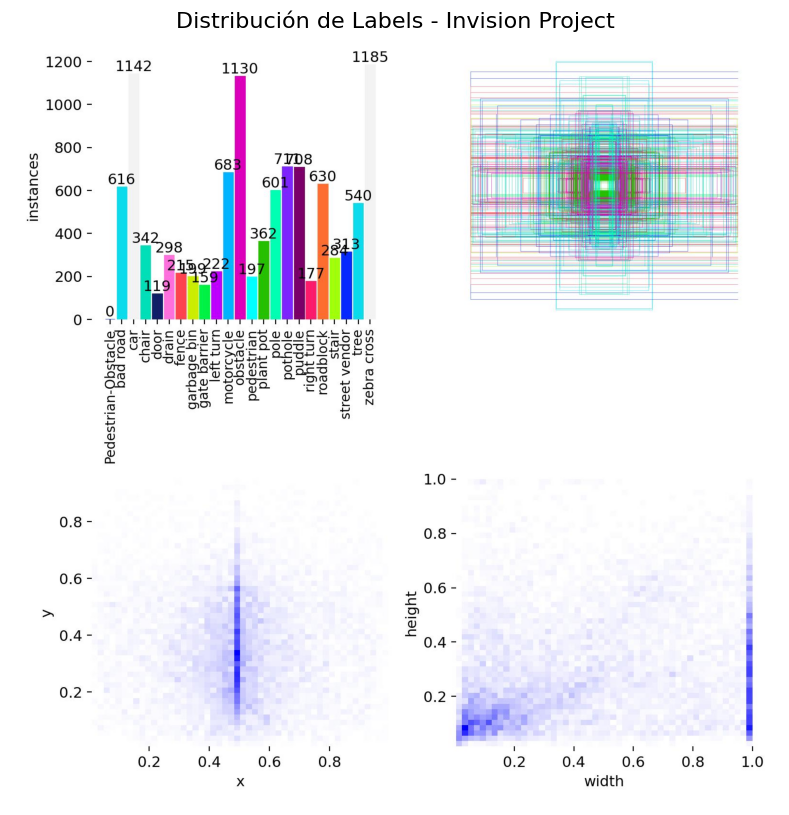

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

labels_path = f'{LAST_RUN_DIR}/labels.jpg'

img = Image.open(labels_path)
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')
plt.title('Distribución de Labels - Invision Project', fontsize=16)
plt.show()


# Testing the YOLOv5n Model

This section focuses on evaluating the performance of the trained YOLOv5n model on unseen data. We will select a random image from the test set, compute its ground truth labels, and then use the model to predict objects within that image. Finally, we will visualize both the ground truth and the model's predictions side-by-side to assess its accuracy and object localization capabilities.

In [8]:
# Folder paths (Ensure these are correct in your Drive)
TEST_IMAGES_PATH = f'{PROJECT_DIR}/pedestrianobstacledetection/test/images'
TEST_LABELS_PATH = f'{PROJECT_DIR}/pedestrianobstacledetection/test/labels'

### Choosing a Random Image for Testing

This section randomly selects an image from the test dataset to be used for model evaluation. This allows us to observe the model's performance on unseen data and visualize its predictions against the ground truth. A corresponding label file for this image will also be identified.

In [9]:
import os
import random

all_images = [f for f in os.listdir(TEST_IMAGES_PATH) if f.endswith(('.jpg', '.png', '.jpeg'))]
random_image_name = random.choice(all_images)
image_path = os.path.join(TEST_IMAGES_PATH, random_image_name)
label_path = os.path.join(TEST_LABELS_PATH, random_image_name.rsplit('.', 1)[0] + '.txt')

### Computing the real label

This section processes the ground truth labels for the selected image. It reads the YOLO-formatted `.txt` file, converts the normalized bounding box coordinates back to pixel values, and then draws these ground truth boxes and their corresponding class labels onto the image. This visual representation allows for a direct comparison with the model's predictions.

In [10]:
import cv2

img_gt = cv2.imread(image_path)
h, w, _ = img_gt.shape

if os.path.exists(label_path):
    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x, y, nw, nh = map(float, line.split())
            # Convert YOLO coordinates (normalized) to pixels
            x1 = int((x - nw/2) * w)
            y1 = int((y - nh/2) * h)
            x2 = int((x + nw/2) * w)
            y2 = int((y + nh/2) * h)

            # Draw bounding box and text
            cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green for ground truth
            label_text = f"GROUND TRUTH: {CLASS_NAMES[int(cls)]}"
            cv2.putText(img_gt, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
else:
    print("⚠️ No label file found for this image.")

### Let the model predict the random image

This section uses the trained YOLOv5n model to perform inference on the randomly selected image. The `model.predict()` function will process the image, detect objects based on the learned weights, and generate bounding box predictions along with class labels and confidence scores. The results will then be used to visualize these predictions on the image.

In [11]:
# The first process is always slow because the model is loaded into memory
results = model.predict(source=image_path, conf=0.3, verbose=False)
img_prediction = results[0].plot() # YOLO already draws the prediction boxes

### Testing the performance

In [ ]:
import time
import torch

# Warm-up
# The first process is always slow because the model is loaded into memory
results = model.predict(source=image_path, conf=0.3, verbose=False)
img_prediction = results[0].plot() # YOLO already draws the prediction boxes

# Full Cycle Measurement (Pure Inference)
# We will process the same image 30 times to get a real average
tiempos = []

for _ in range(30):
    start_time = time.time()
    results = model.predict(source=image_path, conf=0.3, verbose=False)
    end_time = time.time()
    tiempos.append(end_time - start_time)

# Calculations
avg_time_s = sum(tiempos) / len(tiempos)
avg_time_ms = avg_time_s * 1000
fps = 1 / avg_time_s

print("="*40)
print(f"⏱️ INVISION PERFORMANCE")
print("-" * 40)
print(f"Average time per image: {avg_time_ms:.2f} ms")
print(f"Processing capacity: {fps:.2f} FPS")
print("-" * 40)

⏱️ INVISION PERFORMANCE
----------------------------------------
Average time per image: 219.20 ms
Processing capacity: 4.56 FPS
----------------------------------------


In [ ]:
# Fetch the number of CPU cores
num_cores = !lscpu | grep 'CPU(s):' | awk '{print $2}'
num_cores = num_cores[0].strip()

# Fetch the CPU speed (MHz) from the first CPU entry
cpu_mhz = !cat /proc/cpuinfo | grep 'cpu MHz' | head -n 1 | awk '{print $4}'
cpu_mhz = cpu_mhz[0].strip()

print(f"Number of CPU Cores: {num_cores}")
print(f"CPU Velocity (MHz): {cpu_mhz}")

Number of CPU Cores: 2
CPU Velocity (MHz): 2200.178


### Display the Combined Ground Truth and Model Predictions

This section displays the final visualization, which combines the original image with both the ground truth bounding boxes and the model's predicted bounding boxes. This side-by-side comparison allows for a clear assessment of the model's accuracy, object localization, and potential errors in detection or classification.

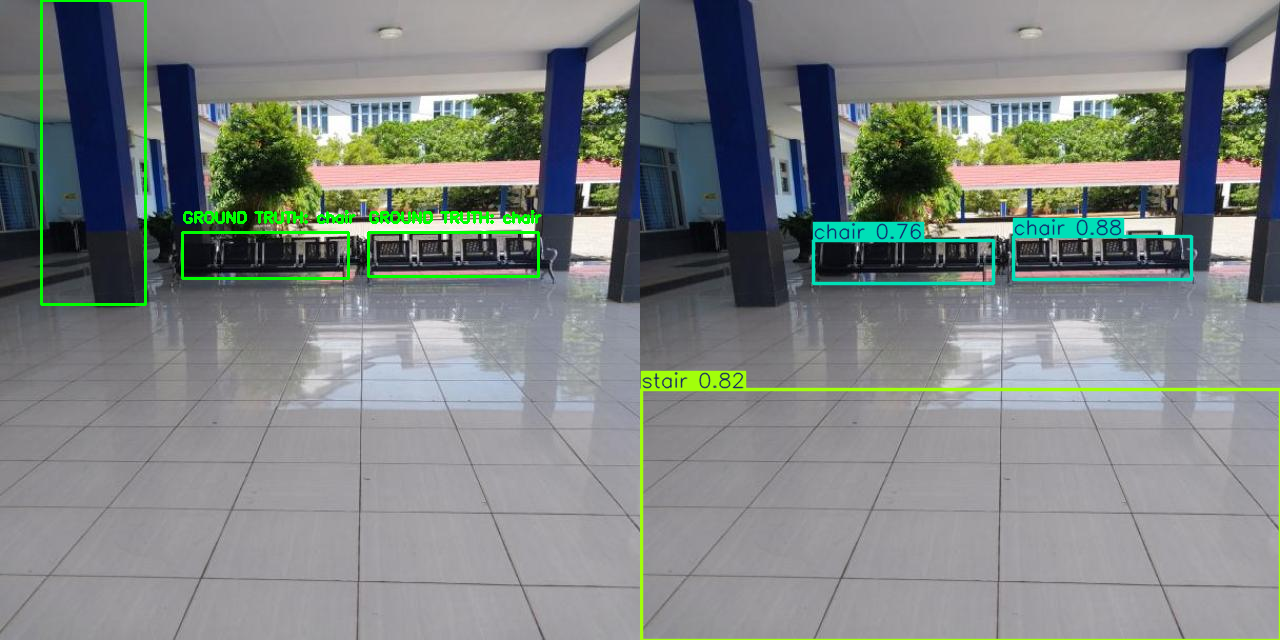

In [12]:
from google.colab.patches import cv2_imshow
import numpy as np


combined_img = np.hstack((img_gt, img_prediction))
cv2_imshow(combined_img)

# Runnging the test data


## Evaluating Model Performance on the Test Set

This section focuses on a comprehensive evaluation of the trained YOLOv5n model's performance on the **unseen test dataset**. We will use the `model.val()` method, which is specifically designed for validation, to compute key object detection metrics. By specifying `split='test'`, we ensure that the model is evaluated on data it has not encountered during training or validation, providing an unbiased assessment of its generalization capabilities.

In [ ]:
# Validate against the TEST set
# We use split='test' to ensure the data is completely new to the model
metrics = model.val(data=YAML_FILE, split='test')

# Print professional metrics
print("\n" + "="*40)
print(f"📊 FINAL RESULTS - TEST SET")
print(f"Directory: {LAST_RUN_DIR}")
print("-" * 40)
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")
print("="*40)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 1.3±1.6 ms, read: 6.7±6.4 MB/s, size: 83.1 KB)
val: Scanning /content/drive/MyDrive/dataset-invision/pedestrianobstacledetection/test/labels.cache... 339 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 339/339 52.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 6.3s/it 2:19
                   all        339        530      0.769      0.713      0.763      0.511
              bad road         28         32      0.894       0.75      0.866      0.463
                   car         42         44      0.794      0.841      0.875      0.635
                 chair         24         28      0.813      0.776      0.836      0.596
                  door          3          4      0.835          1      0.995      0.704
                 drain         12         12      0.831          1       0.97      

The results from the test set evaluation are crucial for understanding how well the model will perform in real-world scenarios. The `mAP50`, `mAP50-95`, Precision, and Recall metrics provide a comprehensive overview of the model's accuracy in both detecting and classifying objects, as well as the quality of its bounding box predictions.

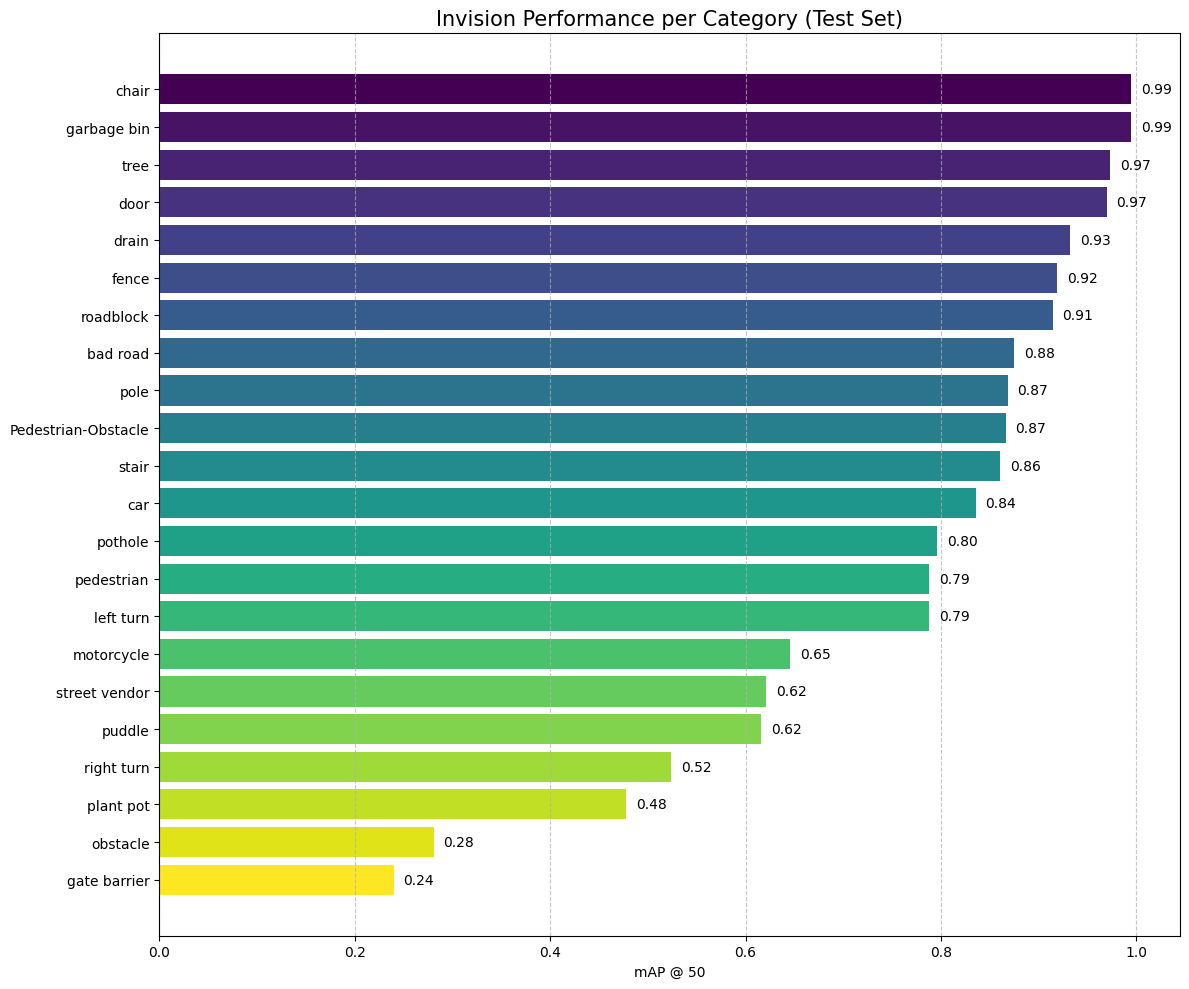


⚠️ SECURITY ALERT:
Classes ['obstacle', 'gate barrier'] have performance below 40%.
Remember that if the model fails in these detections, the system must return -1.


In [ ]:
# Extract class names their respective mAP50
maps_per_class = metrics.box.maps  # This gives the mAP50-95 for each class by default in YOLOv8/v11
# Note: If you prefer to visualize exact mAP50, YOLO saves it in results_test.box.map50

# Create a list of tuples (Name, Value) to sort
data_to_plot = []
for i, mAP in enumerate(metrics.box.ap50): # Using ap50 for mAP@.50
    data_to_plot.append((CLASS_NAMES[i], mAP))

# Sort from highest to lowest for better histogram readability
data_to_plot.sort(key=lambda x: x[1], reverse=True)
labels, values = zip(*data_to_plot)

# Create the plot
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(labels))) # Beautiful colors

bars = plt.barh(labels, values, color=colors)
plt.xlabel('mAP @ 50')
plt.title('Invision Performance per Category (Test Set)', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the numerical value at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=10)

plt.gca().invert_yaxis() # Put the best class at the top
plt.tight_layout()
plt.show()

# 5. Security reminder based on your rules:
low_perf_classes = [l for l, v in data_to_plot if v < 0.4]
if low_perf_classes:
    print(f"\n⚠️ SECURITY ALERT:")
    print(f"Classes {low_perf_classes} have performance below 40%.")
    print("Remember that if the model fails in these detections, the system must return -1.")

### Understanding mAP50 vs mAP50-95

The `mAP50` and `mAP50-95` metrics are both used to evaluate object detection models, but they differ in how strictly they assess the accuracy of bounding box predictions:

*   **mAP50 (Mean Average Precision at IoU 0.50):** This metric calculates the Average Precision (AP) for each class, assuming a minimum Intersection over Union (IoU) threshold of 0.50. IoU measures the overlap between the predicted bounding box and the ground truth bounding box. If the IoU is 0.50 or higher, the detection is considered a True Positive. `mAP50` then averages these APs across all classes. It's a common and less stringent metric, indicating if the model is generally identifying objects correctly and roughly localizing them.

*   **mAP50-95 (Mean Average Precision averaged over IoU thresholds from 0.50 to 0.95):** This is a more comprehensive and rigorous metric. Instead of using a single IoU threshold, it calculates the Average Precision at multiple IoU thresholds (typically 0.50, 0.55, 0.60, ..., 0.95) and then averages these AP values. This means a detection must have a very high overlap with the ground truth (e.g., 95%) to be considered a True Positive at the higher thresholds. `mAP50-95` gives a better indication of how precisely the model localizes objects, as it penalizes less accurate bounding box predictions more heavily. If your `mAP50-95` is significantly lower than your `mAP50`, it suggests your model is good at finding objects but struggles with precise localization (i.e., its bounding boxes are not tight enough around the objects).

# Demo Example

This section is dedicated to demonstrating the trained YOLOv5n model on a single image.

In [44]:
from PIL import Image

# This cell selects and loads an image from the 'images_examples' directory for demonstration.
img_path = f'{PROJECT_DIR}/images_examples/26.jpeg'
img = Image.open(img_path)
# img = img.resize((640, 640))

In [45]:
results = model(img) # Run the YOLOv5 model on the image to get detection results

2 pedestrians, 


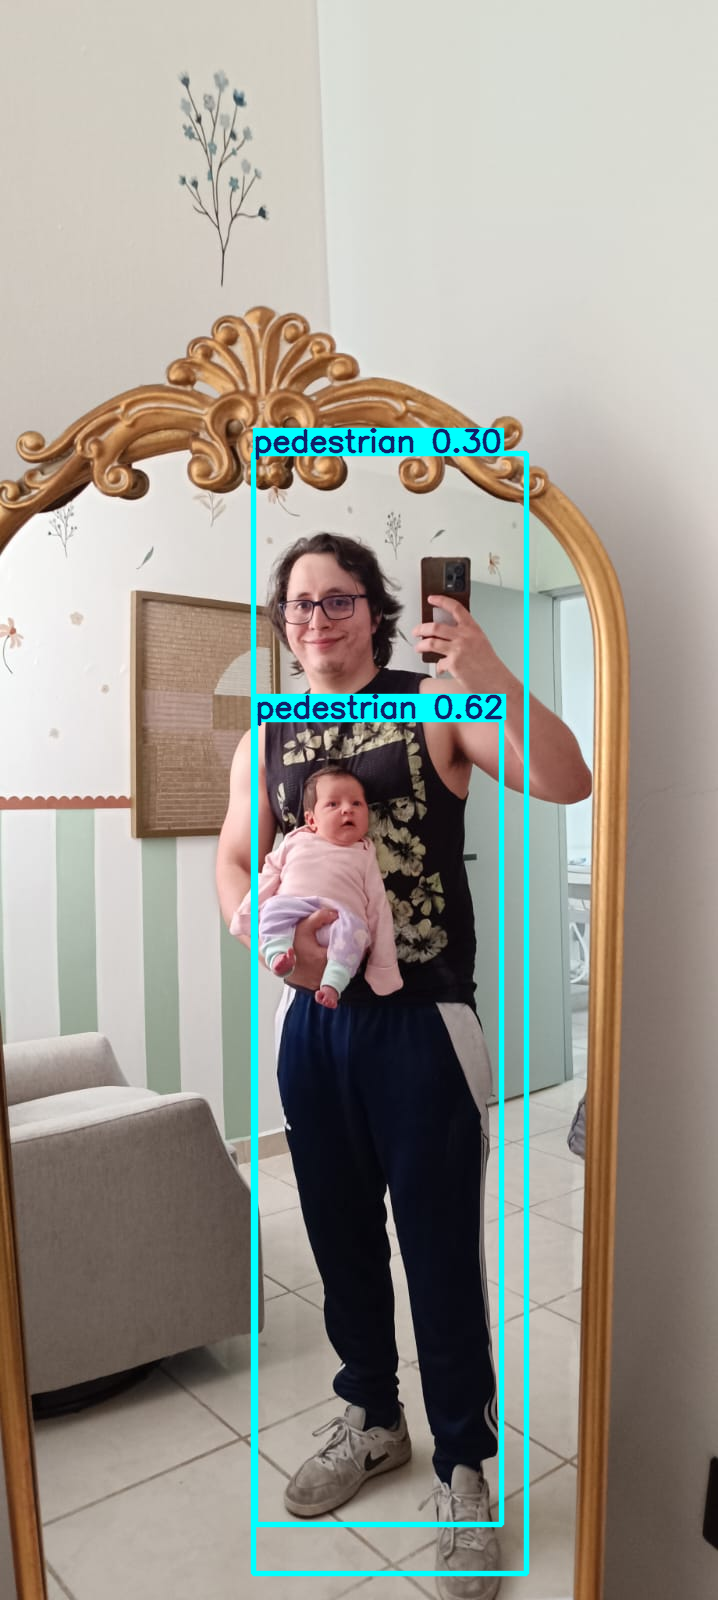

In [46]:
print(results[0].verbose())  # Print results to console using verbose method
results[0].show()   # Pop up the image with bounding boxes